# Projet Machine Learning - MSDE7
## Prediction du Defaut de Remboursement d'un Pret Immobilier
### Problematique

**Classification binaire** : predire si un emprunteur sera en defaut (`Status=1`) ou non (`Status=0`).

**Dataset** : 148 670 prets, 34 variables (demographiques, financieres, contractuelles). Source : [Kaggle - Loan Default Dataset](https://www.kaggle.com/datasets/yasserh/loan-default-dataset)

## 2. Analyse Exploratoire des Donnees (EDA)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Chargement
df = pd.read_csv('Loan_Default.csv')
print(f"Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"\nVariable cible 'Status' :")
print(df['Status'].value_counts())
print(f"\nTaux de defaut : {df['Status'].mean()*100:.2f}%")

# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(f"\nValeurs manquantes :")
print(pd.DataFrame({'N': missing, '%': missing_pct})[missing > 0].sort_values('%', ascending=False))

Dataset : 148670 lignes x 34 colonnes

Variable cible 'Status' :
Status
0    112031
1     36639
Name: count, dtype: int64

Taux de defaut : 24.64%

Valeurs manquantes :
                               N      %
Upfront_charges            39642  26.66
Interest_rate_spread       36639  24.64
rate_of_interest           36439  24.51
dtir1                      24121  16.22
property_value             15098  10.16
LTV                        15098  10.16
income                      9150   6.15
loan_limit                  3344   2.25
approv_in_adv                908   0.61
age                          200   0.13
submission_of_application    200   0.13
loan_purpose                 134   0.09
Neg_ammortization            121   0.08
term                          41   0.03


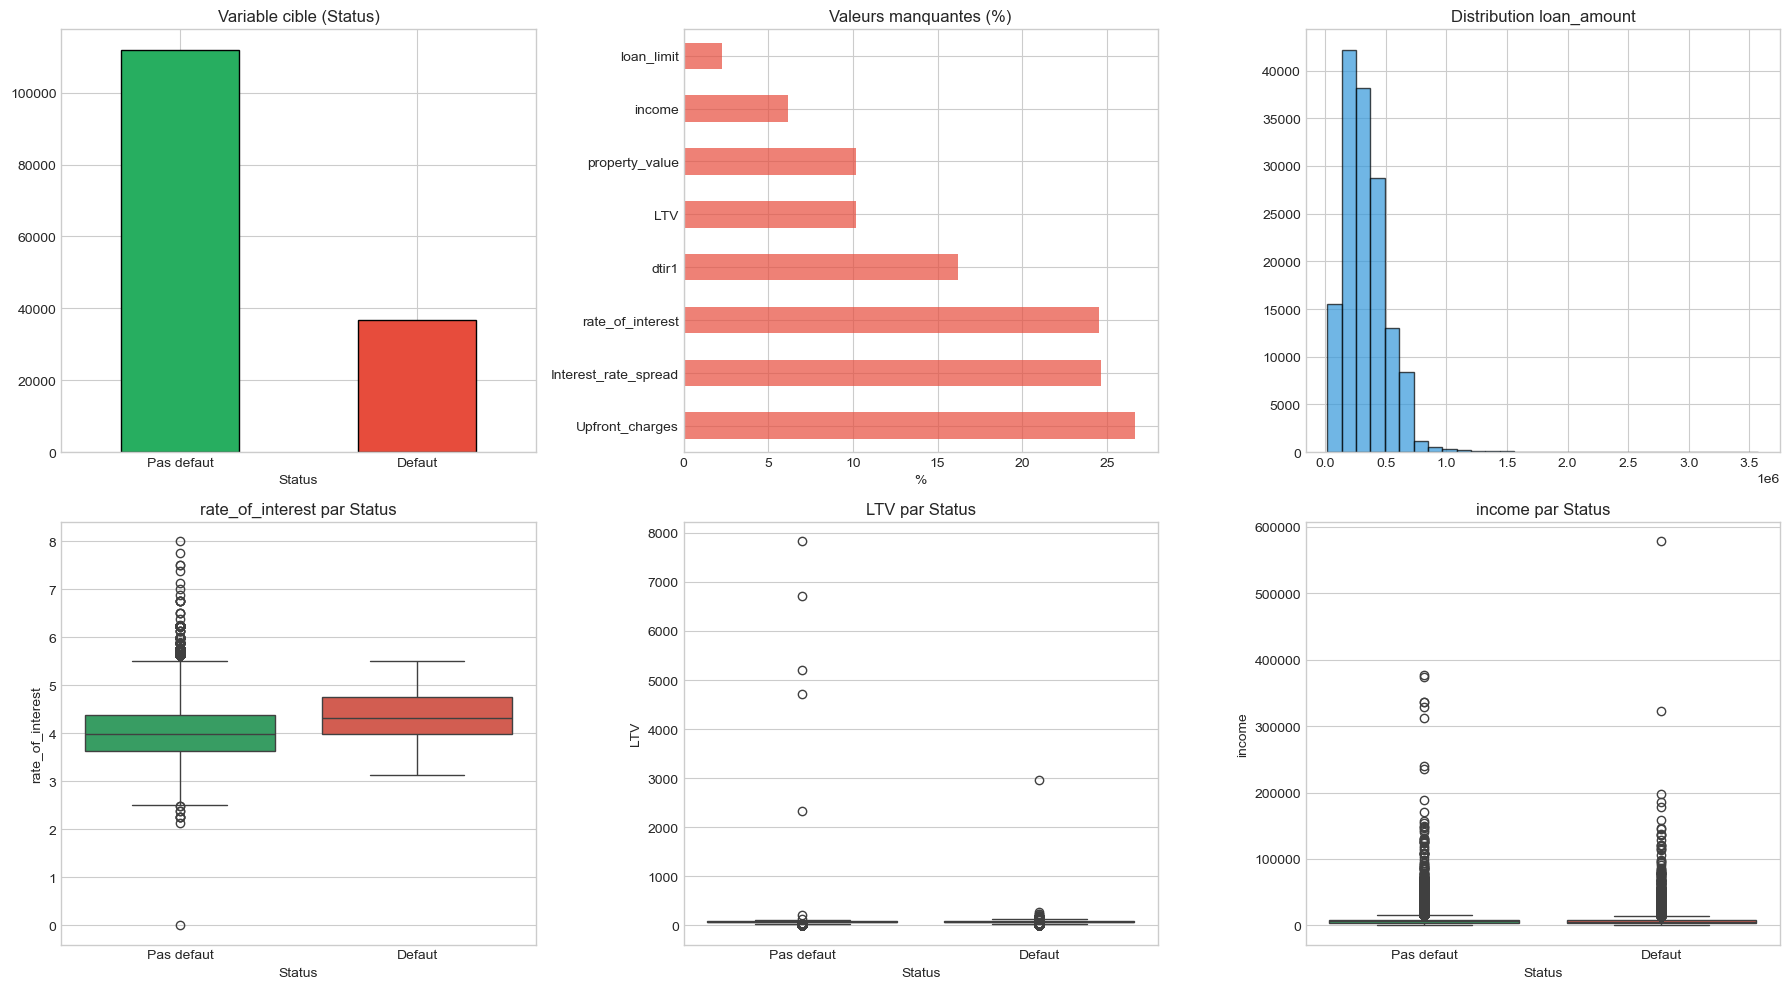

In [2]:
# Visualisations EDA : cible + distributions + correlations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Repartition cible
colors = ['#27ae60', '#e74c3c']
df['Status'].value_counts().plot(kind='bar', color=colors, ax=axes[0,0], edgecolor='black')
axes[0,0].set_title('Variable cible (Status)'); axes[0,0].set_xticklabels(['Pas defaut', 'Defaut'], rotation=0)

# 2. Valeurs manquantes
cols_miss = pd.Series((df.isnull().sum()/len(df)*100)).sort_values(ascending=False).head(8)
cols_miss[cols_miss>0].plot(kind='barh', ax=axes[0,1], color='#e74c3c', alpha=0.7)
axes[0,1].set_title('Valeurs manquantes (%)'); axes[0,1].set_xlabel('%')

# 3. Distribution loan_amount
df['loan_amount'].hist(bins=30, ax=axes[0,2], color='#3498db', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Distribution loan_amount')

# 4-5. Boxplots cles par Status
sns.boxplot(x='Status', y='rate_of_interest', data=df, ax=axes[1,0], palette=colors)
axes[1,0].set_title('rate_of_interest par Status'); axes[1,0].set_xticklabels(['Pas defaut', 'Defaut'])

sns.boxplot(x='Status', y='LTV', data=df, ax=axes[1,1], palette=colors)
axes[1,1].set_title('LTV par Status'); axes[1,1].set_xticklabels(['Pas defaut', 'Defaut'])

sns.boxplot(x='Status', y='income', data=df, ax=axes[1,2], palette=colors)
axes[1,2].set_title('income par Status'); axes[1,2].set_xticklabels(['Pas defaut', 'Defaut'])

plt.tight_layout(); plt.show(); plt.close('all')

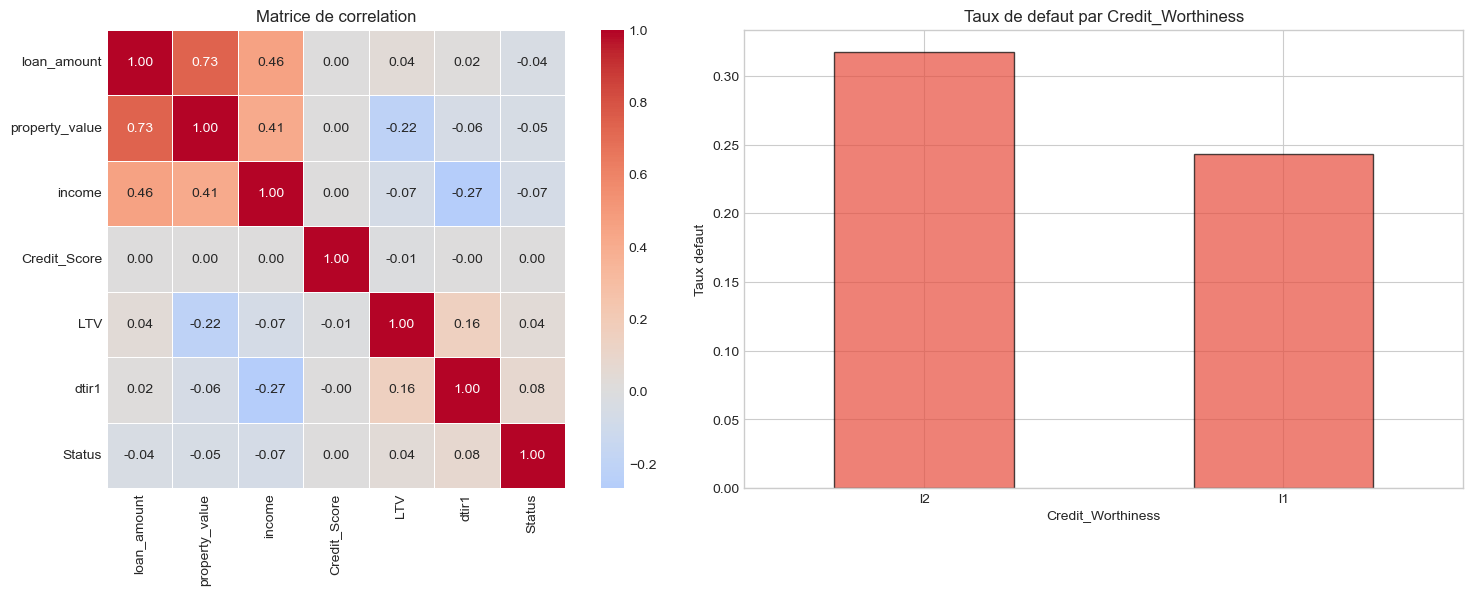


Conclusion EDA : Variables discriminantes = Credit_Worthiness, LTV, Credit_Score, dtir1
ATTENTION : rate_of_interest, Interest_rate_spread, Upfront_charges sont quasi-100% NaN pour les defauts -> DATA LEAKAGE -> supprimees


In [3]:
# Matrice de correlation + variables categorielles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation (sans les variables a fuite : rate_of_interest, Interest_rate_spread, Upfront_charges)
num_corr = ['loan_amount', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1', 'Status']
sns.heatmap(df[num_corr].corr(), annot=True, cmap='coolwarm', center=0, ax=axes[0], fmt='.2f', square=True, linewidths=0.5)
axes[0].set_title('Matrice de correlation')

# Taux de defaut par Credit_Worthiness et Region
cat_rates = df.groupby('Credit_Worthiness')['Status'].mean().sort_values(ascending=False)
cat_rates.plot(kind='bar', ax=axes[1], color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Taux de defaut par Credit_Worthiness'); axes[1].set_ylabel('Taux defaut')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout(); plt.show(); plt.close('all')

print("\nConclusion EDA : Variables discriminantes = Credit_Worthiness, LTV, Credit_Score, dtir1")
print("ATTENTION : rate_of_interest, Interest_rate_spread, Upfront_charges sont quasi-100% NaN pour les defauts -> DATA LEAKAGE -> supprimees")


## 3. Pre-processing

- **Suppression des colonnes a fuite** : `rate_of_interest`, `Interest_rate_spread`, `Upfront_charges` (quasi-100% NaN pour les defauts = data leakage)
- Suppression de `ID` (non predictif)
- Valeurs manquantes : mediane (numeriques), mode (categorielles)
- Encodage : LabelEncoder pour les variables categorielles
- Normalisation : StandardScaler
- Split : 80% train / 20% test avec stratification


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Preparation
df_clean = df.drop('ID', axis=1)

# SUPPRESSION DATA LEAKAGE : ces 3 colonnes sont quasi-100% NaN quand Status=1
leaky_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']
df_clean = df_clean.drop(columns=leaky_cols)
print(f"Colonnes a fuite supprimees : {leaky_cols}")

y = df_clean.pop('Status').values

# Types de variables
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Valeurs manquantes : mediane (num) / mode (cat)
for col in numerical_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in categorical_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Encodage LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Normalisation + Split
feature_names = df_clean.columns.tolist()
scaler = StandardScaler()
X = scaler.fit_transform(df_clean)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")
print(f"Taux defaut - Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")


Colonnes a fuite supprimees : ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']
Train: 118936 | Test: 29734 | Features: 29
Taux defaut - Train: 24.6% | Test: 24.6%


## 4. Entrainement de 10 Modeles ML

Algorithmes testes couvrant les principales familles : lineaire, arbres, ensemble, boosting, bayesien, reseau de neurones.
`class_weight='balanced'` pour compenser le desequilibre des classes (75/25).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, recall_score, 
                             precision_score, classification_report, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

# 10 modeles (pas de SVM car trop lent sur 148K lignes)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=15),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', 
                             verbosity=0, scale_pos_weight=3, n_jobs=-1),
}

# Entrainement + evaluation
results = []
print(f"{'Modele':<22} {'Acc':>6} {'F1':>6} {'AUC':>6} {'Recall':>6} {'Prec':>6}")
print("-" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    acc_tr = accuracy_score(y_train, model.predict(X_train))
    
    results.append({'Modele': name, 'Acc_Train': acc_tr, 'Acc_Test': acc, 
                    'F1': f1, 'AUC': auc, 'Recall': rec, 'Precision': prec})
    print(f"{name:<22} {acc:>6.4f} {f1:>6.4f} {auc:>6.4f} {rec:>6.4f} {prec:>6.4f}")

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(f"\nTop modele : {results_df.iloc[0]['Modele']} (AUC={results_df.iloc[0]['AUC']:.4f})")

Modele                    Acc     F1    AUC Recall   Prec
-------------------------------------------------------
Logistic Regression    0.6792 0.5011 0.7312 0.6538 0.4062
KNN (k=5)              0.8408 0.6132 0.7988 0.5120 0.7642
Decision Tree          0.8662 0.7141 0.8435 0.6779 0.7543
Random Forest          0.8903 0.7276 0.8885 0.5947 0.9370
Gradient Boosting      0.8971 0.7493 0.8936 0.6242 0.9371
AdaBoost               0.8611 0.6271 0.8442 0.4738 0.9269
Extra Trees            0.8766 0.6844 0.8766 0.5430 0.9253
Bagging                0.8922 0.7436 0.8832 0.6340 0.8990
Naive Bayes            0.7684 0.1528 0.7133 0.0847 0.7772
XGBoost                0.8753 0.7426 0.8949 0.7301 0.7555

Top modele : XGBoost (AUC=0.8949)


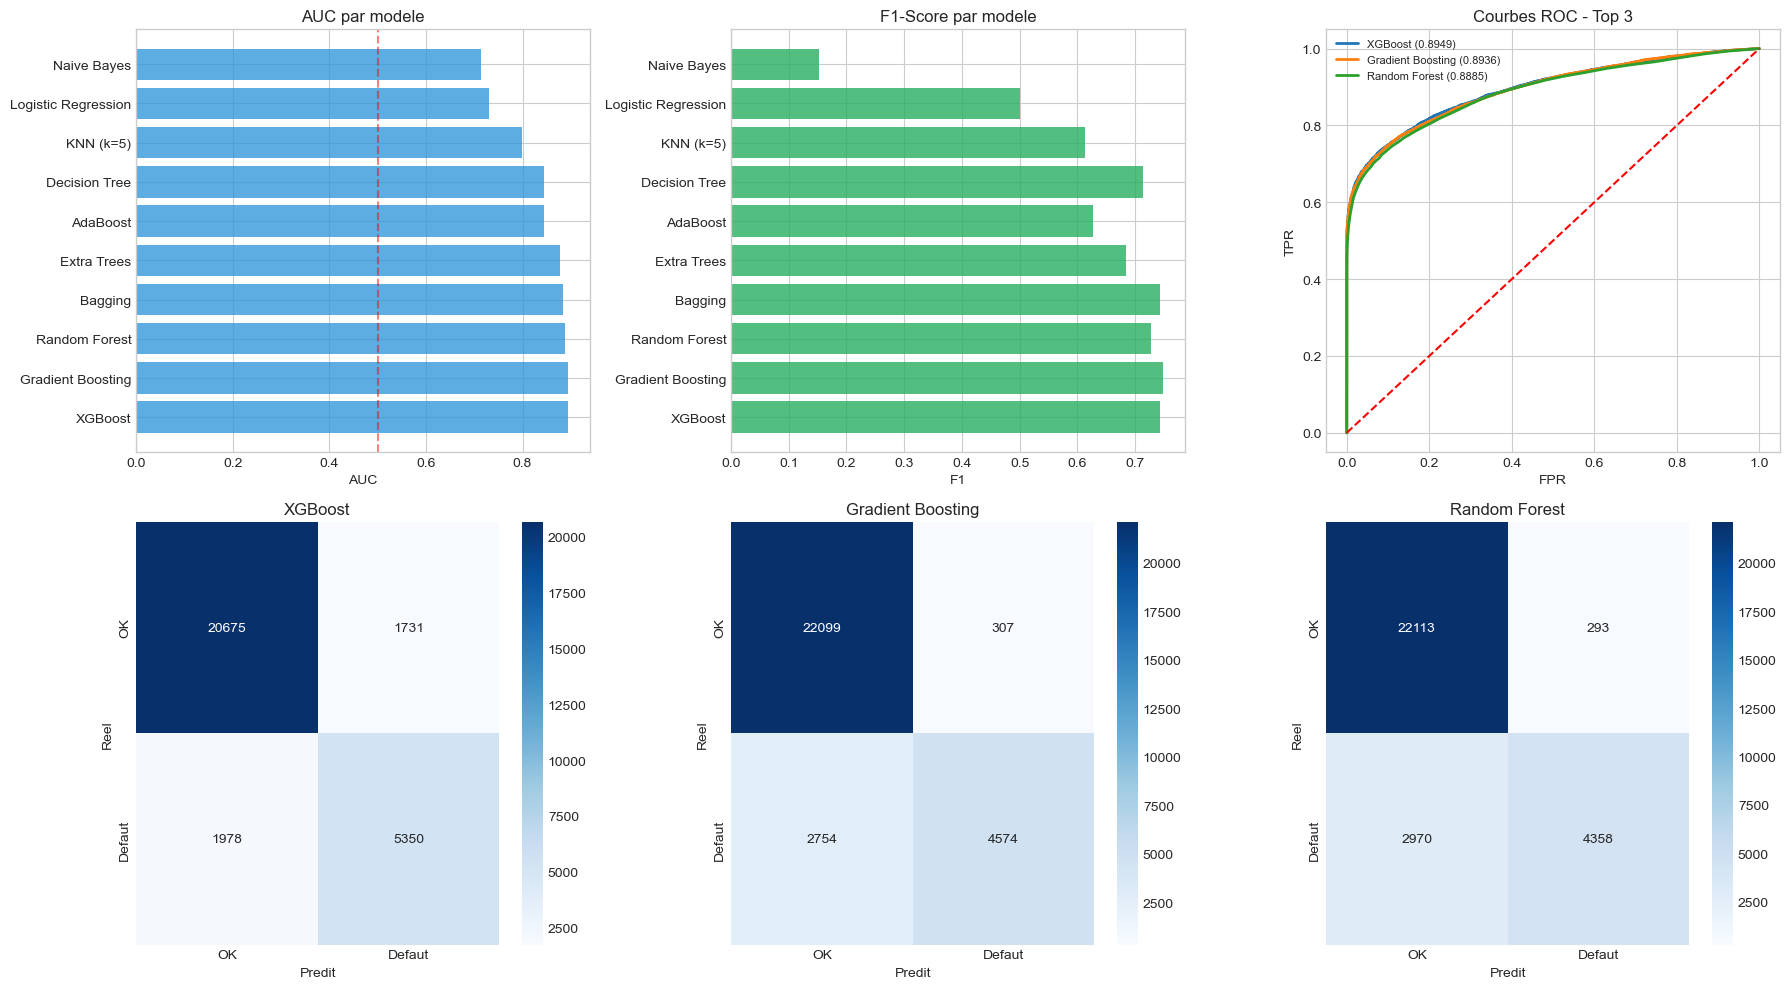

In [6]:
# Visualisation comparative + Matrices de confusion Top 3
top3 = results_df.head(3)['Modele'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Barres AUC et F1
axes[0,0].barh(results_df['Modele'], results_df['AUC'], color='#3498db', alpha=0.8)
axes[0,0].set_xlabel('AUC'); axes[0,0].set_title('AUC par modele')
axes[0,0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

axes[0,1].barh(results_df['Modele'], results_df['F1'], color='#27ae60', alpha=0.8)
axes[0,1].set_xlabel('F1'); axes[0,1].set_title('F1-Score par modele')

# Courbes ROC Top 3
for name in top3:
    m = models[name]
    yp = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    axes[0,2].plot(fpr, tpr, linewidth=2, label=f"{name} ({roc_auc_score(y_test, yp):.4f})")
axes[0,2].plot([0,1],[0,1],'r--'); axes[0,2].set_title('Courbes ROC - Top 3')
axes[0,2].legend(fontsize=8); axes[0,2].set_xlabel('FPR'); axes[0,2].set_ylabel('TPR')

# Matrices de confusion Top 3
for i, name in enumerate(top3):
    cm = confusion_matrix(y_test, models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,i],
                xticklabels=['OK','Defaut'], yticklabels=['OK','Defaut'])
    axes[1,i].set_title(f'{name}'); axes[1,i].set_xlabel('Predit'); axes[1,i].set_ylabel('Reel')

plt.tight_layout(); plt.show(); plt.close('all')

## 5. Tuning des 3 Meilleurs Modeles (RandomizedSearchCV)

In [7]:
from sklearn.model_selection import RandomizedSearchCV

# Grilles d'hyperparametres (reduites pour rapidite)
param_grids = {
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 15, 20],
                      'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
                'max_depth': [5, 6, 7], 'subsample': [0.8, 0.9],
                'colsample_bytree': [0.8, 0.9], 'scale_pos_weight': [3, 4]},
    'Extra Trees': {'n_estimators': [100, 200], 'max_depth': [10, 15, 20],
                    'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
                          'max_depth': [3, 5], 'subsample': [0.8, 0.9]},
    'Decision Tree': {'max_depth': [5, 10, 15, 20], 'min_samples_split': [2, 5, 10],
                      'min_samples_leaf': [1, 2, 5]},
    'Bagging': {'n_estimators': [100, 200], 'max_samples': [0.8, 0.9, 1.0]},
}

# Tuning Top 3
tuned_models = {}
tuning_results = []

for name in top3:
    print(f"\n{'='*40}\nTuning : {name}\n{'='*40}")
    if name not in param_grids:
        print(f"  Pas de grille, params par defaut conserves")
        tuned_models[name] = models[name]
        r = results_df[results_df['Modele']==name].iloc[0]
        tuning_results.append({'Modele': name, 'AUC_avant': r['AUC'], 'AUC_apres': r['AUC']})
        continue
    
    search = RandomizedSearchCV(models[name], param_grids[name], n_iter=10, cv=2,
                                scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    
    y_proba_t = search.best_estimator_.predict_proba(X_test)[:, 1]
    auc_t = roc_auc_score(y_test, y_proba_t)
    r = results_df[results_df['Modele']==name].iloc[0]
    tuning_results.append({'Modele': name, 'AUC_avant': r['AUC'], 'AUC_apres': auc_t})
    
    print(f"  Best params: {search.best_params_}")
    print(f"  AUC: {r['AUC']:.4f} -> {auc_t:.4f} (gain: {auc_t - r['AUC']:+.4f})")

tuning_df = pd.DataFrame(tuning_results)
print(f"\n\n{'='*40}\nResultats du tuning :\n{'='*40}")
print(tuning_df.to_string(index=False))



Tuning : XGBoost
  Best params: {'subsample': 0.9, 'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
  AUC: 0.8949 -> 0.8985 (gain: +0.0036)

Tuning : Gradient Boosting
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
  AUC: 0.8936 -> 0.8972 (gain: +0.0037)

Tuning : Random Forest
  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
  AUC: 0.8885 -> 0.8928 (gain: +0.0042)


Resultats du tuning :
           Modele  AUC_avant  AUC_apres
          XGBoost   0.894917   0.898527
Gradient Boosting   0.893551   0.897210
    Random Forest   0.888510   0.892757


MODELE FINAL : XGBoost
  Accuracy : 0.8804
  F1-Score : 0.7494
  AUC-ROC  : 0.8985
  Recall   : 0.7257
  Precision: 0.7747

              precision    recall  f1-score   support

  Pas defaut       0.91      0.93      0.92     22406
      Defaut       0.77      0.73      0.75      7328

    accuracy                           0.88     29734
   macro avg       0.84      0.83      0.84     29734
weighted avg       0.88      0.88      0.88     29734



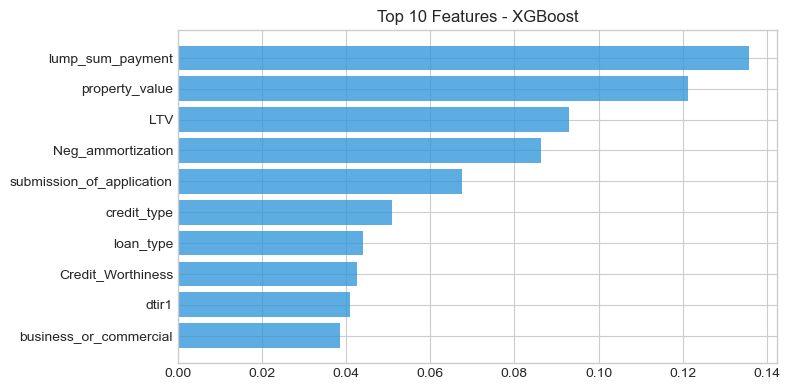

In [8]:
# Modele final : meilleur AUC apres tuning
best_name = tuning_df.sort_values('AUC_apres', ascending=False).iloc[0]['Modele']
final_model = tuned_models[best_name]

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print(f"MODELE FINAL : {best_name}")
print(f"{'='*50}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_final):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['Pas defaut', 'Defaut'])}")

# Feature importance
if hasattr(final_model, 'feature_importances_'):
    feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': final_model.feature_importances_})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498db', alpha=0.8)
    ax.set_title(f'Top 10 Features - {best_name}'); ax.invert_yaxis()
    plt.tight_layout(); plt.show(); plt.close('all')

## 6. Serialisation et Deploiement

Export du pipeline complet (modele + scaler + encodeurs) en pickle pour l'application Streamlit et Flask.

In [9]:
import pickle

# Sauvegarde du pipeline complet
pipeline = {
    'model': final_model, 'model_name': best_name,
    'scaler': scaler, 'label_encoders': label_encoders,
    'feature_names': feature_names,
    'categorical_cols': categorical_cols, 'numerical_cols': numerical_cols
}

with open('pipeline_loan_default.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print(f"Pipeline sauvegarde : pipeline_loan_default.pkl")

# Verification : reload + prediction test
with open('pipeline_loan_default.pkl', 'rb') as f:
    p = pickle.load(f)

pred = p['model'].predict(X_test[:5])
proba = p['model'].predict_proba(X_test[:5])
print(f"\nTest verification (5 echantillons) :")
for i in range(5):
    real = 'Defaut' if y_test[i] == 1 else 'OK'
    predicted = 'Defaut' if pred[i] == 1 else 'OK'
    conf = proba[i].max() * 100
    print(f"  [{i}] Reel: {real:7s} | Predit: {predicted:7s} | Confiance: {conf:.1f}%")

print(f"\nPipeline pret pour le deploiement (Streamlit: app.py, Flask: flask_app.py)")

Pipeline sauvegarde : pipeline_loan_default.pkl

Test verification (5 echantillons) :
  [0] Reel: OK      | Predit: OK      | Confiance: 89.5%
  [1] Reel: OK      | Predit: OK      | Confiance: 90.0%
  [2] Reel: OK      | Predit: OK      | Confiance: 75.9%
  [3] Reel: OK      | Predit: OK      | Confiance: 71.2%
  [4] Reel: OK      | Predit: OK      | Confiance: 68.0%

Pipeline pret pour le deploiement (Streamlit: app.py, Flask: flask_app.py)


## Conclusion

Pipeline ML complet pour la prediction du defaut de pret immobilier :
1. **EDA** : 148 670 obs, 34 variables, cible desequilibree (25% defaut), detection du **data leakage**
2. **Suppression data leakage** : `rate_of_interest`, `Interest_rate_spread`, `Upfront_charges` (quasi-100% NaN pour defauts)
3. **Pre-processing** : Mediane/mode pour NaN, LabelEncoder, StandardScaler, split stratifie 80/20
4. **10 modeles** testes avec metriques completes (Accuracy, F1, AUC, Recall, Precision)
5. **Tuning** Top 3 par RandomizedSearchCV (10 iter, 2-fold CV)
6. **Deploiement** : Pipeline pickle -> Streamlit Cloud + Flask/Render
